# Exploratory Data Analysis

Before training any model, it's important to understand to the data. This notebool explores the distribution of sentiments, review length patterns, the most frequent words per sentiment, and how review volume evolved over time.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud

In [4]:
df = pd.read_csv(r"C:\Users\kumri\Downloads\Data Science Notebooks\AirBnB sentiment analysis\sentiment_tags.csv")
df.head()

,date,reviewer_name,comments,language,exclamation_count,question_count,caps_ratio,word_count,cleaned_comments,sentiment
0,1/18/2020,Santiago,Beca its very lovely! 10/10 recommended!,en,2,0,0.025000,6,beca it very lovely! / recommended!,positive
1,8/10/2020,Serena,Renate is very nice and ready to help. The hou...,en,1,0,0.025381,38,renate be very nice and ready to help. the hou...,positive
2,5/21/2022,Rosemary,"Overall the location was excellent, but the co...",en,0,0,0.005682,60,"overall the location be excellent, but the con...",neutral
3,12/11/2019,Ali,"Highly recommended, good value of money a litt...",en,0,0,0.009804,18,"highly recommended, good value of money a litt...",positive
4,8/27/2016,Zhibo,Suze's house is situated in a very nice and qu...,en,0,0,0.022535,59,suze's house be situate in a very nice and qui...,positive


In [8]:
print(df.shape)
print(df.columns.tolist())

(15116, 10)
['date', 'reviewer_name', 'comments', 'language', 'exclamation_count', 'question_count', 'caps_ratio', 'word_count', 'cleaned_comments', 'sentiment']


## Sentiment distribution

The chart reflects the dataset after downsampling positive reviews to match the neutral class size. Negative reviews remain the minority class with 1514 samples, which will be adressed in the ML notebook using SMOTE to generate synthetic and balance negatives before training.

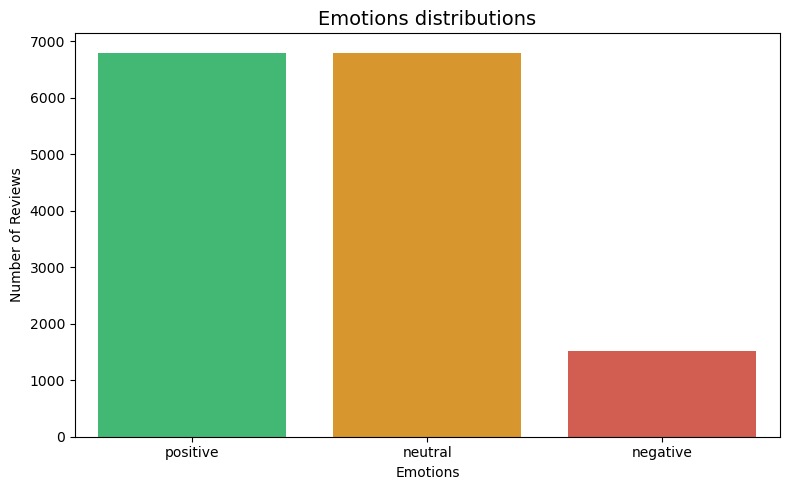

In [16]:
plt.figure(figsize=(8,5))
sns.countplot(data=df, 
              x='sentiment',
              hue='sentiment',
              order=['positive','neutral','negative'],
              palette=['#2ecc71', '#f39c12', '#e74c3c'],
              legend=False)

plt.title('Emotions distributions', fontsize=14)
plt.xlabel('Emotions')
plt.ylabel('Number of Reviews')
plt.tight_layout()
plt.show()

## Review lenght by sentiment  

  An interesting pattern shows, negative reviews tend to be significantly longer than positive ones. When something goes wrong, when something goes wrong, people write more to explain what happened.

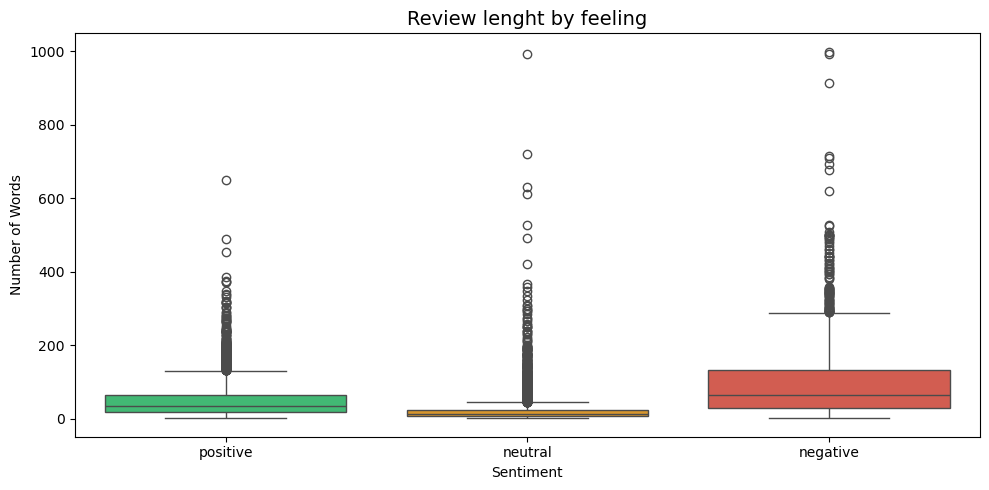

In [14]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df,
            x='sentiment',
            y='word_count',
            order=['positive','neutral','negative'],
            hue='sentiment',
            palette=['#2ecc71', '#f39c12', '#e74c3c'],
            legend=False)

plt.title('Review lenght by feeling',fontsize=14)
plt.xlabel('Sentiment')
plt.ylabel('Number of Words')
plt.tight_layout()
plt.show()

## Most frequent words by Sentiment

The word clouds confirm the pipeline is working correctly. Positive reviews surface words like "great", "stay", "place" while negative reviews highlight specific complaints "room", "location", "host".

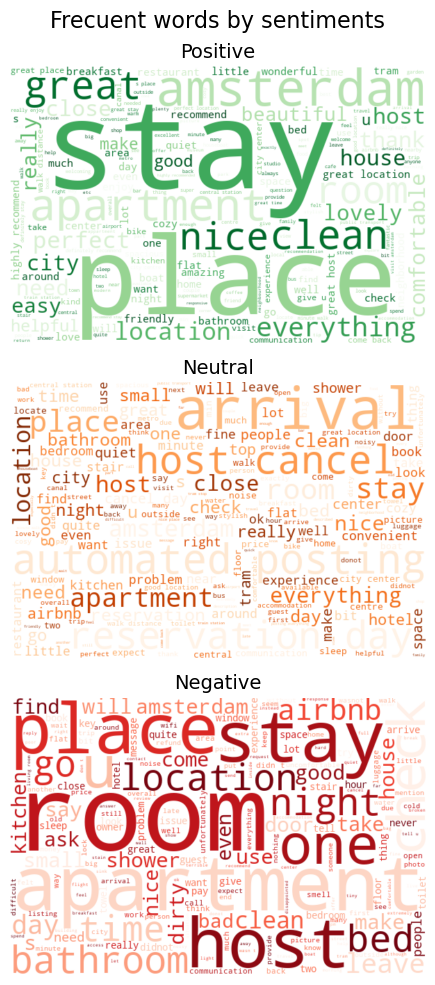

In [23]:
from wordcloud import WordCloud

fig,axes = plt.subplots(3,1,figsize=(20,10))
sentiments = ['positive','neutral','negative']
colors = ['Greens','Oranges','Reds']

for ax, sentiment,color in zip(axes,sentiments,colors):
    text=' '.join(df[df['sentiment'] == sentiment]['cleaned_comments'])

    wordcloud = WordCloud(width=600, 
                          height=400,
                          background_color='white',
                        colormap=color).generate(text)
    
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.set_title(sentiment.capitalize(), fontsize=14)
    ax.axis('off')

plt.suptitle('Frecuent words by sentiments', fontsize=16)
plt.tight_layout()
plt.show()

## Review volume over time

The timeline reveals 2 clear trends: steady growth from 2010 to 2019 reflecting Airbnb's expansion, and a sharp drop in 2020 due to COVID-19 travel restrictions, followed by a strong recovery in 2021-2022.

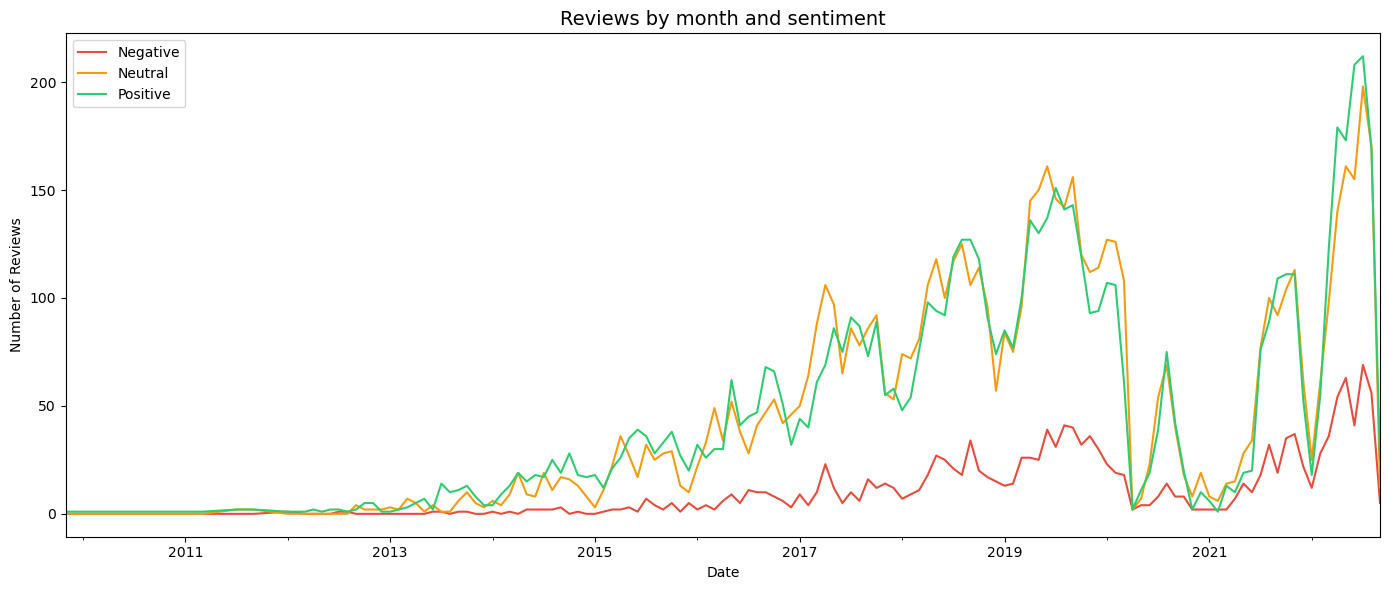

In [32]:
df['date'] = pd.to_datetime(df['date'])
df['year_month'] = df['date'].dt.to_period('M')

timeline = df.groupby(['year_month','sentiment']).size().unstack(fill_value=0)

timeline.plot(figsize=(14,6),
              color=['#e74c3c', '#f39c12', '#2ecc71'])

plt.title('Reviews by month and sentiment', fontsize=14)
plt.xlabel('Date')
plt.ylabel('Number of Reviews')
plt.legend(['Negative','Neutral','Positive'])
plt.tight_layout()
plt.show()